<a href="https://colab.research.google.com/github/vikramshrivastav734-prog/AQI-Prediction-Project/blob/main/01_AQI_Prediction/AQI_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully! Previewing data:
        City        Date  PM2.5  PM10    NO2     CO  AQI
0  Ahmedabad  2015-01-01    NaN   NaN  18.22   0.92  NaN
1  Ahmedabad  2015-01-02    NaN   NaN  15.69   0.97  NaN
2  Ahmedabad  2015-01-03    NaN   NaN  19.30  17.40  NaN
3  Ahmedabad  2015-01-04    NaN   NaN  18.48   1.70  NaN
4  Ahmedabad  2015-01-05    NaN   NaN  21.42  22.10  NaN

Training the Random Forest Regressor model...

Model Performance:
Root Mean Squared Error (RMSE): 42.47
R-squared Score (Accuracy): 89.88%

Saved final plot as 'actual_vs_predicted_aqi.png'


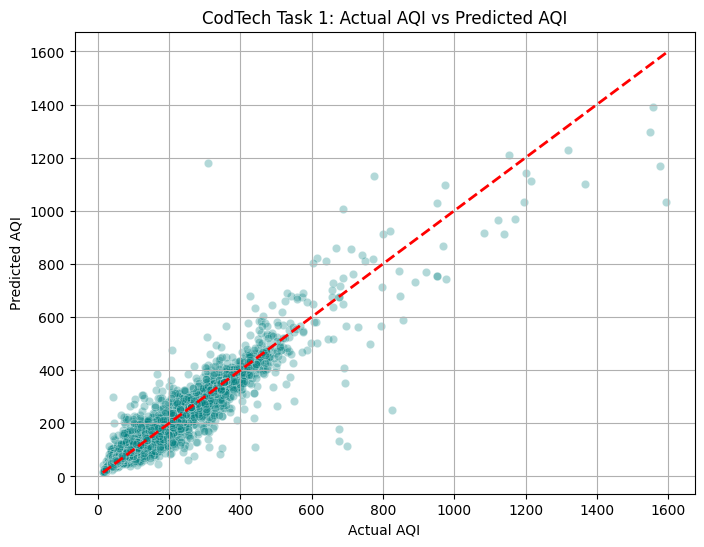

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Downloading dataset directly from GitHub...")
# Live public repository dataset containing Indian cities daily pollution readings
data_url = 'https://raw.githubusercontent.com/learning-monk/datasets/master/Indian_cities_daily_pollution_2015-2020.csv'
df = pd.read_csv(data_url)

print("Dataset loaded successfully! Previewing data:")
print(df[['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'CO', 'AQI']].head())

# 1. Fast Data Cleaning
# Forward-fill and backward-fill missing sensor values
df = df.ffill().bfill()

# 2. Define Features and Target matching this specific dataset schema
features = ['PM2.5', 'PM10', 'NO2', 'CO']
X = df[features]
y = df['AQI']

# 3. Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining the Random Forest Regressor model...")
# 4. Initialize and Train the Model
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Evaluate Model
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n=======================")
print(f"Model Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (Accuracy): {r2*100:.2f}%")
print(f"=======================\n")

# 6. Generate Submission Visual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('CodTech Task 1: Actual AQI vs Predicted AQI')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.grid(True)
plt.savefig('actual_vs_predicted_aqi.png')
print("Saved final plot as 'actual_vs_predicted_aqi.png'")
plt.show()